# **Data preparation**
---

**This notebook focuses on preparing a dataset of environment observations (images) and actions to train the Vision Model (VAE).**

### **Environment - Cart Pole-v1**
---
The [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/)
environment from Gymnasium provides a classic reinforcement learning problem described by Barto, Sutton, and Anderson in [“Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem”](https://ieeexplore.ieee.org/document/6313077).

<img src="../media/cart_pole.gif" alt="Cart Pole" width="500" style="border-radius: 25px;"/>

#### **Environment Details**
Each time the environment resets, a procedurally generated race track is created. The complexity varies significantly - from simple tracks with gentle curves to complex circuits with numerous tight 180° turns.

**Discrete Action Space:**
- 0: Push cart to the left
- 1: Push cart to the right

**Reward Structure:**
Since the goal is to keep the pole upright for as long as possible, by default, a reward of +1 is given for every step taken, including the termination step. The default reward threshold is 500 for v1 and 200 for v0 due to the time limit on the environment.

If `sutton_barto_reward=True`, then a reward of 0 is awarded for every non-terminating step and -1 for the terminating step. As a result, the reward threshold is 0 for v0 and v1.

### **Wrapping environment + image processing**
---

The **CartPole-v1** environment originally provides observations as an array with the values of cart position, cart velocity, pole angle and pole angular velocity. We'll modify it with two wrappers: 

1. AddRenderObservation: modify the observation returned by the environment to be in the pixel space as a 400x600 RGB image.
2. TransformObservation: apply a function to the observation. We'll use it to turn the image into grayscale to make the training smoother.

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:572

Box(0, 255, (400, 600, 3), uint8)


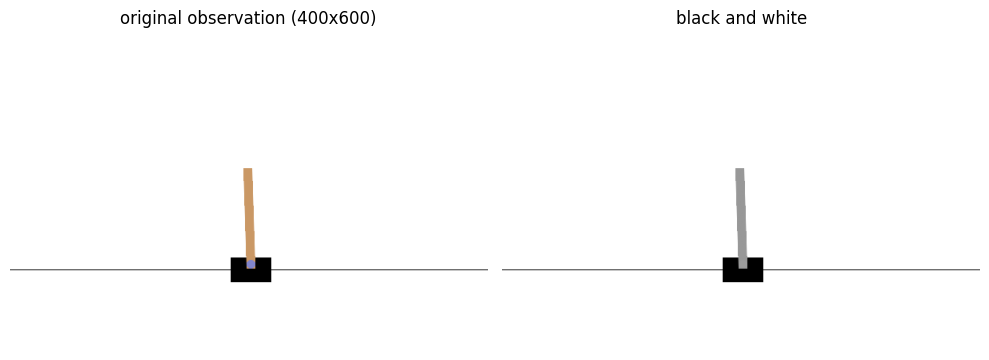

(400, 600, 1)


In [1]:
import gymnasium as gym
from gymnasium.wrappers import AddRenderObservation, TransformObservation
from matplotlib import pyplot as plt
import numpy as np

env = gym.make('CartPole-v1', render_mode="rgb_array")
env = AddRenderObservation(env, render_only=True)
env_bw = TransformObservation(env, lambda obs: np.mean(obs, axis=2, keepdims=True), env.observation_space)
print(env.observation_space)

obs, _ = env.reset(seed=123)
obs_bw, _ = env_bw.reset(seed=123)
image = env.render()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].imshow(obs)
axs[0].set_title('original observation (400x600)')
axs[0].axis('off')

axs[1].imshow(obs_bw, cmap='gray')
axs[1].set_title('black and white')
axs[1].axis('off')

plt.tight_layout()
plt.show()
print(obs_bw.shape)


## **Efficient Data Collection and Storage**
---

To optimize the process of generating a large dataset (e.g., 10.000 episodes), we utilize [HDF5](https://docs.h5py.org/en/stable/) for efficient data storage and parallel processing for data collection.

### Data Collection Strategy

1. **Parallelization**: The workload is distributed across available CPU cores, with each worker handling a portion of the episodes.
2. **Intermediate Storage**: Each worker generates episodes and stores them in temporary HDF5 files.
3. **Dataset Consolidation**: After all episodes are generated, the temporary files are merged into a single HDF5 dataset.
4. **Episode Handling**: If the car goes off-track before completing the 1000 steps, the environment is reset and the episode continues until the full length is reached.

### Final Dataset Structure

```
root:
  actions = float32(num_episodes x 1000 x 2)
  dones   =    bool(num_episodes x 1000)
  images  =   uint8(num_episodes x 1000 x 400 x 600)
  rewards = float32(num_episodes x 1000)
```

In [2]:
import gymnasium as gym
from gymnasium.wrappers import AddRenderObservation, TransformObservation

import matplotlib
matplotlib.use('Agg')  # Non-interactive backend, no X server needed

import numpy as np
import h5py
from multiprocessing import Pool, cpu_count
from PIL import Image
import gc 
import os


def collect_episode(max_steps, episode_id, worker_id, output_dir):
    """
    Collect data for a single episode and write it to an HDF5 file.
    
    Args:
        max_steps (int): Maximum number of steps per episode
        episode_id (int): The episode's unique identifier
        worker_id (int): The worker's unique identifier
        output_dir (str): Directory to store episode files
    """
    # Initialize lists to store episode data
    episode_images = []
    episode_actions = []
    episode_rewards = []
    episode_dones = []
    
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env = AddRenderObservation(env, render_only=True)
    env = TransformObservation(env, lambda obs: np.mean(obs, axis=2, keepdims=True), env.observation_space)
    obs, _ = env.reset()

    for step in range(max_steps):
        # Process and store the observation
        episode_images.append(obs)

        # Generate action (random action every 20 steps)
        if step % 20 == 0:
            action = np.random.randint(0, 2, size=1)
        episode_actions.append(action)

        # Execute action and store results
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards.append(reward)
        episode_dones.append(done)

        # Reset if episode terminates early
        if done:
            obs, _ = env.reset()

    # Convert lists to NumPy arrays
    episode_images = np.array(episode_images, dtype=np.uint8)
    episode_actions = np.array(episode_actions, dtype=np.float32)
    episode_rewards = np.array(episode_rewards, dtype=np.float32)
    episode_dones = np.array(episode_dones, dtype=bool)

    # Define the episode file path
    episode_filename = f'worker_{worker_id}_episode_{episode_id}.h5'
    episode_path = os.path.join(output_dir, episode_filename)

    # Write the episode data to an HDF5 file
    with h5py.File(episode_path, 'w') as h5f:
        h5f.create_dataset('images', data=episode_images, dtype='uint8')
        h5f.create_dataset('actions', data=episode_actions, dtype='float32')
        h5f.create_dataset('rewards', data=episode_rewards, dtype='float32')
        h5f.create_dataset('dones', data=episode_dones, dtype='bool')

    # Clean up memory
    env.close()
    del episode_images, episode_actions, episode_rewards, episode_dones
    del action, reward, done, truncated, info, obs, env
    gc.collect()  # Explicitly trigger garbage collection
    

def collect_data_worker(args):
    """
    Worker function to collect multiple episodes and write each to a separate file.
    
    Args:
        args: Tuple containing (num_episodes, max_steps, output_dir, worker_id)
    """
    num_episodes, max_steps, output_dir, worker_id = args

    print(f"Starting worker {worker_id}\n")

    for ep in range(num_episodes):
        collect_episode(max_steps, ep, worker_id, output_dir)
        print(f"Worker {worker_id}: Episode ({ep+1}/{num_episodes}) completed")

    print(f"Worker {worker_id}: Completed {num_episodes} episodes.")


def collect_data(num_episodes=100, max_steps=1000, 
                output_dir='../data/vae', num_workers=None):
    """
    Collect data from the environment and store each episode in a separate HDF5 file.
    
    Args:
        num_episodes (int): Total number of episodes to generate
        max_steps (int): Maximum steps per episode
        output_dir (str): Directory to store episode files
        num_workers (int, optional): Number of worker processes. Defaults to CPU count
    """
    if num_workers is None:
        num_workers = cpu_count()-1 # Use all available CPU cores

    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Determine episodes per worker
    episodes_per_worker = num_episodes // num_workers
    remaining_episodes = num_episodes % num_workers

    # Prepare arguments for each worker
    worker_args = []
    for i in range(num_workers):
        worker_episodes = episodes_per_worker + (1 if i < remaining_episodes else 0)
        args = (worker_episodes, max_steps, output_dir, i)
        worker_args.append(args)

    # Use Pool for multiprocessing with controlled number of workers
    with Pool(processes=num_workers) as pool:
        list(pool.imap_unordered(collect_data_worker, worker_args))

    
    print("Data collection completed.")

In [3]:
%%time
collect_data(num_episodes=128, max_steps=500, output_dir='../data/raw')

Starting worker 1
Starting worker 0
Starting worker 2





ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No su

KeyboardInterrupt: 

### **Consolidating Episodes into a Single Dataset**
After collecting individual episode data files, we need to merge them into a unified dataset structure for efficient training access.

In [7]:
import os
import h5py
from tqdm import tqdm

def merge_episode_files(episodes_dir='../data/raw',
                        output_file='merged_data.h5', 
                        env_name='CartPole-v1',
                        num_max_steps=1000):
    """
    Merge multiple episode HDF5 files into a single HDF5 dataset.
    
    Args:
        episodes_dir (str): Directory containing individual episode files
        output_file (str): Path for the consolidated output file
        env_name (str): Environment name (for documentation purposes)
        num_max_steps (int): Expected number of steps per episode
    """
    # Step 1: Locate all episode files
    episode_files = [
        os.path.join(episodes_dir, f)
        for f in os.listdir(episodes_dir)
        if f.endswith('.h5') or f.endswith('.hdf5')
    ]

    num_episodes = len(episode_files)
    if num_episodes == 0:
        raise ValueError(f"No HDF5 episode files found in directory: {episodes_dir}")

    print(f"Found {num_episodes} episode files in '{episodes_dir}'.")

    # Optional: Sort files for consistent ordering
    episode_files.sort()

    # Step 2: Verify episode integrity
    for file in episode_files:
        with h5py.File(file, 'r') as h5f:
            actions_shape = h5f['actions'].shape
            if actions_shape[0] != num_max_steps:
                raise ValueError(
                    f"Episode file {file} has {actions_shape[0]} steps, expected {num_max_steps}."
                )

    # Step 3: Initialize the merged HDF5 file
    with h5py.File(output_file, 'w') as merged_h5f:
        # Initialize datasets with optimized chunking
        actions_shape = (num_episodes, num_max_steps)
        dones_shape = (num_episodes, num_max_steps)
        images_shape = (num_episodes, num_max_steps, 400, 600, 1)
        rewards_shape = (num_episodes, num_max_steps)

        print("Initializing datasets in the merged HDF5 file...")
        merged_h5f.create_dataset('actions', shape=actions_shape,
                                 dtype='float16', chunks=(1, num_max_steps))
        merged_h5f.create_dataset('dones', shape=dones_shape,
                                 dtype='bool', chunks=(1, num_max_steps))
        merged_h5f.create_dataset('images', shape=images_shape,
                                 dtype='uint8', chunks=(1, num_max_steps, 400, 600, 1))
        merged_h5f.create_dataset('rewards', shape=rewards_shape,
                                 dtype='int', chunks=(1, num_max_steps))

        # Step 4: Iterate through each episode and write to the merged file
        for idx, episode_file in enumerate(tqdm(episode_files, desc="Merging Episodes")):
            with h5py.File(episode_file, 'r') as ep_h5f:
                # Read datasets from the episode file
                actions = ep_h5f['actions'][:]
                dones = ep_h5f['dones'][:]
                images = ep_h5f['images'][:]
                rewards = ep_h5f['rewards'][:]

                # Write to the merged datasets
                merged_h5f['actions'][idx] = actions
                merged_h5f['dones'][idx, :] = dones
                merged_h5f['images'][idx, :, :] = images
                merged_h5f['rewards'][idx, :] = rewards

            # Step 5: Clean up temporary files
            try:
                os.remove(episode_file)
            except Exception as de:
                print(f"Error deleting temporary file '{episode_file}': {de}")

    print(f"Merging completed successfully. Merged data saved to '{output_file}'.")


# Merge the previously generated episode files
merge_episode_files(episodes_dir='../data/raw', 
                   output_file='../data/cart_pole_data_128.h5', 
                   env_name='CartPole-v1', 
                   num_max_steps=500)

Found 128 episode files in '../data/raw'.
Initializing datasets in the merged HDF5 file...


Merging Episodes: 100%|██████████| 128/128 [01:31<00:00,  1.40it/s]

Merging completed successfully. Merged data saved to '../data/cart_pole_data_128.h5'.


In [13]:
import nexusformat.nexus as nx

# Verify dataset structure
f = nx.nxload('../data/vae_data.h5')
print(f.tree)

root:NXroot
  actions = float16(128x500)
  dones = bool(128x500)
  images = uint8(128x500x400x600x1)
  rewards = int64(128x500)


### **Creating PyTorch Dataset**
To efficiently use our collected data for model training, we'll implement a custom PyTorch Dataset that provides streaming access to the HDF5 file.

In [2]:
import os
import sys
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from jepacartpole.datasets import CartPoleVAEDataset

### **Visualizing the Dataset**

This allows us to inspect the images in sequence, ensuring they're properly stored and aligned with their respective episode and step information.

In [6]:
import pygame
from torch.utils.data import DataLoader
import numpy as np

def display_dataset(dataloader, scale=1):
    """
    Visualize the dataset using Pygame.
    
    Args:
        dataloader: PyTorch DataLoader containing the dataset
        scale (int): Scale factor for display window
    """
    pygame.init()
    pygame.font.init()

    # Configure pygame window
    image_size = 96
    window_size = (int(image_size * scale), int(image_size * scale))
    screen = pygame.display.set_mode(window_size)
    pygame.display.set_caption('Dataset Visualizer')
    clock = pygame.time.Clock()  

    rollout_id = 0
    step = 0

    for images, actions, rewards, dones in dataloader:
        # Process the image for display
        images = images.squeeze().permute(1, 0).cpu().numpy()  
        images = (images * 255).astype(np.uint8)  
        images = pygame.surfarray.make_surface(images)

        # Set a grayscale palette (0=black, 255=white)
        grayscale_palette = [(i, i, i) for i in range(256)]
        images.set_palette(grayscale_palette)

        images = pygame.transform.scale(images, window_size)  

        # Draw the image to screen
        screen.blit(images, (0, 0))

        # Add rollout and step information overlay
        font = pygame.font.SysFont(None, 24)
        text = font.render(f'Rollout: {rollout_id} Step: {step}', True, (255, 255, 255))
        screen.blit(text, (10, 10))

        pygame.display.update()

        # Control playback speed
        clock.tick(60)  # 60 FPS
        
        # Update step/episode counters
        step += 1
        if step == 1000:  # End of episode
            step = 0
            rollout_id += 1

        # Check for exit command
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return

    pygame.quit()

# Create dataset and dataloader
dataset = CartPoleVAEDataset()
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Launch the visualizer
display_dataset(dataloader, scale=4)

# ** World Model Dataset **